In [3]:
import os
import json
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import tensorflow as tf

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.layers import (
    Input,
    Embedding,
    Bidirectional,
    LSTM,
    GlobalMaxPooling1D,
    Dense,
    Dropout,
    Concatenate,
    Lambda
)

from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint
)

warnings.filterwarnings("ignore")

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


In [5]:
import os

print(os.listdir('/content/sample_data'))

['anscombe.json', 'README.md', 'train.jsonl', 'mnist_train_small.csv', 'california_housing_train.csv', 'california_housing_test.csv', 'mnist_test.csv']


In [6]:
DATA_PATH = "/content/sample_data/train.jsonl"

In [7]:
import json

data = []

with open(DATA_PATH, "r", encoding="utf-8") as f:
    for line in f:
        data.append(json.loads(line))

print(f"Total records: {len(data)}")

Total records: 50000


In [8]:
data[0]

{'Job-Description': '\n\n## Job Title\nOracle SCM Developer\n\n## Job Summary\nThe role of Oracle SCM Developer calls for an experienced professional with expertise in using SQL, the ERP tool, and thorough understanding of Supply Chain Management, Bills of Materials (BOM), and Work in Progress (WIP) sections. We are looking for an outright professional who has been pivotal in handling comprehensive SCM operations, developing Oracle-run resourcing frameworks, analyzing scenario-driven networks, and facilitating cloud-based endeavors towards the resultant development processes.\n\n## Required Skills\n- Proficiency in SQL for creating computing solutions.\n- In-depth knowledge of ERP to integrate various organizational systems.\n- Thorough understanding of Supply chain operations including cost curation & evaluations.  \n- Comprehensive use of BOM systems.\n- Demonstrative experience with Work in Progress (WIP) sections.\n\n## Required Experience\n- 3 years as an Oracle SCM Developer.\n- 

In [9]:
print(data[0].keys())

dict_keys(['Job-Description', 'Resume-matched', 'Resume-unmatched', 'Skills', 'Experiences', 'Experiences-years', 'Filtered-information'])


In [10]:
# ==========================================
# Cell 3: Create Training Pairs
# ==========================================

pairs = []

for row in data:

    jd = row["Job-Description"]

    matched_resume = row["Resume-matched"]
    unmatched_resume = row["Resume-unmatched"]

    # Positive Pair
    pairs.append({
        "resume": matched_resume,
        "job_description": jd,
        "label": 1
    })

    # Negative Pair
    pairs.append({
        "resume": unmatched_resume,
        "job_description": jd,
        "label": 0
    })

df = pd.DataFrame(pairs)

print("Total training pairs:", len(df))
df.head()

Total training pairs: 100000


,resume,job_description,label
0,\n\n## Personal Information\nName: Konstantina...,\n\n## Job Title\nOracle SCM Developer\n\n## J...,1
1,\n\n## Personal Information\nName: Konstantina...,\n\n## Job Title\nOracle SCM Developer\n\n## J...,0
2,\n\n## Personal Information\nName: Yelena Belo...,"\n\n## Job Title\nElectrical, Electronic, and ...",1
3,\n\n## Personal Information\nName: Yelena Belo...,"\n\n## Job Title\nElectrical, Electronic, and ...",0
4,\n\n## Personal Information\nName: Matthew Ste...,\n\n## Job Title\nUI - Sr. Java Tech Lead (Por...,1


In [11]:
print(df.shape)
print()

print(df["label"].value_counts())
print()

df.sample(5)

(100000, 3)

label
1    50000
0    50000
Name: count, dtype: int64



,resume,job_description,label
75721,**\n## Personal Information\nJacob's distinct ...,\n\n## Job title\nOccupational Therapy Aide\n\...,0
80184,\n\n## Personal Information\nName: Relja Mira\...,\n\n## Job title\nSecretaries and Administrati...,1
19864,\n\n##### Personal Information\nName: Mohammad...,\n\n#### Job title\nCOBOL Programmer with SAS ...,1
76699,\n\n## Personal Information\nName: Livia Thomp...,\n\n## Job Title\nDesktop Technician - Level I...,0
92991,\n\n## Personal Information\nName: Mei-Ling \n...,\n\n## Job title\nCIM Engineer / Database Admi...,0


In [12]:
print(df.isnull().sum())

resume             0
job_description    0
label              0
dtype: int64


In [13]:
# Number of words in each resume
df["resume_length"] = df["resume"].apply(lambda x: len(x.split()))

# Number of words in each JD
df["jd_length"] = df["job_description"].apply(lambda x: len(x.split()))

print(df[["resume_length", "jd_length"]].describe())

       resume_length      jd_length
count  100000.000000  100000.000000
mean       91.391620     177.755120
std        29.431993      35.799491
min        22.000000      67.000000
25%        70.000000     153.000000
50%        88.000000     173.000000
75%       109.000000     198.000000
max       599.000000     424.000000


In [14]:
df[["resume_length", "jd_length"]].describe()

,resume_length,jd_length
count,100000.000000,100000.000000
mean,91.391620,177.755120
std,29.431993,35.799491
min,22.000000,67.000000
25%,70.000000,153.000000
50%,88.000000,173.000000
75%,109.000000,198.000000
max,599.000000,424.000000


In [15]:
# ==========================================
# Cell 7: Text Preprocessing
# ==========================================

import re

def clean_text(text):
    # Convert to lowercase
    text = text.lower()

    # Remove extra spaces and newlines
    text = re.sub(r'\s+', ' ', text)

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # Keep only letters, numbers and common programming symbols
    text = re.sub(r'[^a-zA-Z0-9+#./ ]', ' ', text)

    # Remove repeated spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [16]:
df["resume"] = df["resume"].apply(clean_text)
df["job_description"] = df["job_description"].apply(clean_text)

print("Cleaning completed!")

Cleaning completed!


In [17]:
resume_texts = df["resume"].tolist()
jd_texts = df["job_description"].tolist()

labels = df["label"].values

In [18]:
VOCAB_SIZE = 30000

tokenizer = Tokenizer(
    num_words=VOCAB_SIZE,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(resume_texts + jd_texts)

print("Vocabulary Size:", len(tokenizer.word_index))

Vocabulary Size: 112297


In [19]:
resume_sequences = tokenizer.texts_to_sequences(resume_texts)
jd_sequences = tokenizer.texts_to_sequences(jd_texts)

In [20]:
resume_lengths = [len(seq) for seq in resume_sequences]
jd_lengths = [len(seq) for seq in jd_sequences]

print("Resume")
print(pd.Series(resume_lengths).describe())

print("\nJob Description")
print(pd.Series(jd_lengths).describe())

Resume
count    100000.000000
mean         83.600340
std          28.490036
min          19.000000
25%          63.000000
50%          80.000000
75%         100.000000
max         602.000000
dtype: float64

Job Description
count    100000.000000
mean        165.641100
std          34.628658
min          68.000000
25%         142.000000
50%         161.000000
75%         185.000000
max         414.000000
dtype: float64


In [21]:
MAX_LENGTH = 256

In [22]:
# ==========================================
# Cell 12: Padding Sequences
# ==========================================

MAX_LENGTH = 256

resume_padded = pad_sequences(
    resume_sequences,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

jd_padded = pad_sequences(
    jd_sequences,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

print("Resume Shape:", resume_padded.shape)
print("JD Shape:", jd_padded.shape)

Resume Shape: (100000, 256)
JD Shape: (100000, 256)


In [23]:
# ==========================================
# Cell 13: Train / Validation / Test Split
# ==========================================

X_resume_train, X_resume_temp, X_jd_train, X_jd_temp, y_train, y_temp = train_test_split(
    resume_padded,
    jd_padded,
    labels,
    test_size=0.20,
    random_state=42,
    stratify=labels
)

X_resume_val, X_resume_test, X_jd_val, X_jd_test, y_val, y_test = train_test_split(
    X_resume_temp,
    X_jd_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Training Set:", X_resume_train.shape[0])
print("Validation Set:", X_resume_val.shape[0])
print("Test Set:", X_resume_test.shape[0])

Training Set: 80000
Validation Set: 10000
Test Set: 10000


In [24]:
print("Resume Train:", X_resume_train.shape)
print("JD Train:", X_jd_train.shape)

print("Resume Validation:", X_resume_val.shape)
print("JD Validation:", X_jd_val.shape)

print("Resume Test:", X_resume_test.shape)
print("JD Test:", X_jd_test.shape)

Resume Train: (80000, 256)
JD Train: (80000, 256)
Resume Validation: (10000, 256)
JD Validation: (10000, 256)
Resume Test: (10000, 256)
JD Test: (10000, 256)


In [25]:
# ==========================================
# Cell 15: Shared Encoder
# ==========================================

from tensorflow.keras.layers import (
    Input,
    Embedding,
    Bidirectional,
    LSTM,
    GlobalMaxPooling1D
)
from tensorflow.keras.models import Model

EMBEDDING_DIM = 128
LSTM_UNITS = 64

def build_encoder():

    input_layer = Input(shape=(MAX_LENGTH,))

    x = Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM
    )(input_layer)

    x = Bidirectional(
        LSTM(
            LSTM_UNITS,
            return_sequences=True
        )
    )(x)

    x = GlobalMaxPooling1D()(x)

    return Model(input_layer, x, name="Encoder")

In [26]:
encoder = build_encoder()

encoder.summary()

Model: "Encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 256, 128)       │     3,840,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 256, 128)       │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,938,816 (15.03 MB)

 Trainable params: 3,938,816 (15.03 MB)

 Non-trainable params: 0 (0.00 B)

In [27]:
# ==========================================
# Cell 17: Siamese Network
# ==========================================

from tensorflow.keras.layers import (
    Dense,
    Dropout,
    Concatenate,
    Lambda
)

resume_input = Input(shape=(MAX_LENGTH,), name="Resume")

jd_input = Input(shape=(MAX_LENGTH,), name="JobDescription")

resume_vector = encoder(resume_input)

jd_vector = encoder(jd_input)

In [28]:
absolute_difference = Lambda(
    lambda tensors: tf.abs(tensors[0] - tensors[1])
)([resume_vector, jd_vector])

elementwise_product = Lambda(
    lambda tensors: tensors[0] * tensors[1]
)([resume_vector, jd_vector])

In [29]:
merged = Concatenate()([
    resume_vector,
    jd_vector,
    absolute_difference,
    elementwise_product
])

In [30]:
x = Dense(128, activation="relu")(merged)

x = Dropout(0.30)(x)

x = Dense(64, activation="relu")(x)

output = Dense(
    1,
    activation="sigmoid",
    name="Prediction"
)(x)

In [31]:
model = Model(
    inputs=[resume_input, jd_input],
    outputs=output
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Resume (InputLayer) │ (None, 256)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ JobDescription      │ (None, 256)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Encoder             │ (None, 128)       │  3,938,816 │ Resume[0][0],     │
│ (Functional)        │                   │            │ JobDescription[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 128)       │          0 │ Encoder[0][0],    │
│                     │                   │            │ Encoder[1][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 128)       │          0 │ Encoder[0][0],    │
│                     │                   │            │ Encoder[1][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 512)       │          0 │ Encoder[0][0],    │
│ (Concatenate)       │                   │            │ Encoder[1][0],    │
│                     │                   │            │ lambda[0][0],     │
│                     │                   │            │ lambda_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     65,664 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      8,256 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Prediction (Dense)  │ (None, 1)         │         65 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,012,801 (15.31 MB)

 Trainable params: 4,012,801 (15.31 MB)

 Non-trainable params: 0 (0.00 B)

In [33]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

In [34]:
# ==========================================
# Cell 22: Callbacks
# ==========================================

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "best_resume_match_model.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

In [35]:
# ==========================================
# Cell 23: Train Model
# ==========================================

history = model.fit(
    [X_resume_train, X_jd_train],
    y_train,

    validation_data=(
        [X_resume_val, X_jd_val],
        y_val
    ),

    epochs=10,
    batch_size=32,

    callbacks=[
        early_stopping,
        checkpoint
    ],

    verbose=1
)

Epoch 1/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 0s 549ms/step - accuracy: 0.6669 - loss: 0.5899 - precision: 0.6576 - recall: 0.6716
Epoch 1: val_loss improved from None to 0.43979, saving model to best_resume_match_model.keras

Epoch 1: finished saving model to best_resume_match_model.keras
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 1424s 567ms/step - accuracy: 0.7293 - loss: 0.5239 - precision: 0.7143 - recall: 0.7643 - val_accuracy: 0.7894 - val_loss: 0.4398 - val_precision: 0.7980 - val_recall: 0.7750
Epoch 2/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 0s 561ms/step - accuracy: 0.8251 - loss: 0.3875 - precision: 0.8034 - recall: 0.8590
Epoch 2: val_loss improved from 0.43979 to 0.38283, saving model to best_resume_match_model.keras

Epoch 2: finished saving model to best_resume_match_model.keras
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 1485s 594ms/step - accuracy: 0.8423 - loss: 0.3584 - precision: 0.8230 - recall: 0.8721 - val_accuracy: 0.8250 - val_loss: 0.3828 - val_precision: 0.7982 - val_recall: 0.8700
Epoch 3/10


In [36]:
# ==========================================
# Cell 25: Evaluate on Test Set
# ==========================================

test_loss, test_accuracy, test_precision, test_recall = model.evaluate(
    [X_resume_test, X_jd_test],
    y_test,
    verbose=1
)

print(f"\nTest Accuracy : {test_accuracy:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall   : {test_recall:.4f}")
print(f"Test Loss     : {test_loss:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 44s 142ms/step - accuracy: 0.8459 - loss: 0.3688 - precision: 0.8529 - recall: 0.8360

Test Accuracy : 0.8459
Test Precision: 0.8529
Test Recall   : 0.8360
Test Loss     : 0.3688


In [37]:
import numpy as np

y_prob = model.predict(
    [X_resume_test, X_jd_test]
)

y_pred = (y_prob > 0.5).astype(int)

313/313 ━━━━━━━━━━━━━━━━━━━━ 46s 145ms/step


In [38]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.86      0.85      5000
           1       0.85      0.84      0.84      5000

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



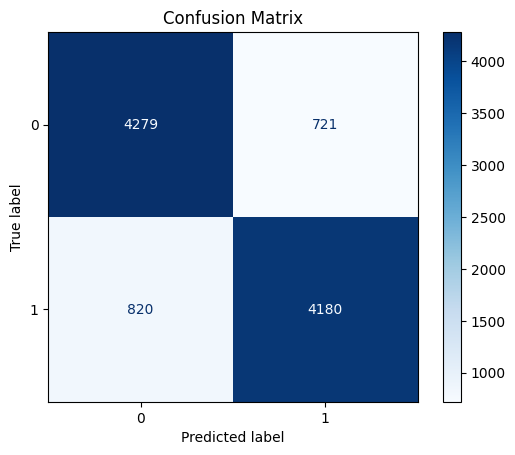

In [39]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(cm)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

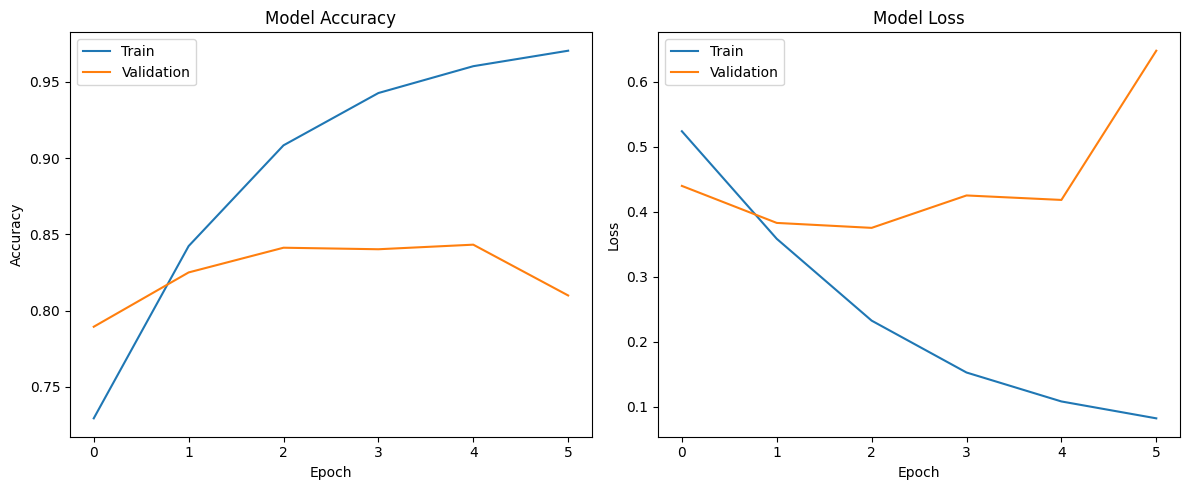

In [40]:
# ==========================================
# Cell 29: Training Curves
# ==========================================

plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Validation")
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Validation")
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [41]:
model.save("resume_jd_matcher.keras")

print("Model saved successfully!")

Model saved successfully!


In [42]:
import pickle

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

print("Tokenizer saved successfully!")

Tokenizer saved successfully!


In [43]:
def predict_match(resume_text, job_description):

    # Clean
    resume_text = clean_text(resume_text)
    job_description = clean_text(job_description)

    # Tokenize
    resume_seq = tokenizer.texts_to_sequences([resume_text])
    jd_seq = tokenizer.texts_to_sequences([job_description])

    # Pad
    resume_pad = pad_sequences(
        resume_seq,
        maxlen=MAX_LENGTH,
        padding="post",
        truncating="post"
    )

    jd_pad = pad_sequences(
        jd_seq,
        maxlen=MAX_LENGTH,
        padding="post",
        truncating="post"
    )

    probability = model.predict([resume_pad, jd_pad], verbose=0)[0][0]

    prediction = "Matched" if probability >= 0.5 else "Not Matched"

    print(f"Match Probability : {probability:.4f}")
    print(f"Prediction        : {prediction}")

    return probability

In [44]:
resume = """
Python Developer
TensorFlow
SQL
Machine Learning
Pandas
Power BI
"""

job = """
Looking for a Python Developer with experience in
TensorFlow, SQL, Data Analysis and Machine Learning.
"""

predict_match(resume, job)

Match Probability : 0.0565
Prediction        : Not Matched


np.float32(0.056456305)